In [1]:
import pandas as pd
import numpy as np

In [2]:
data = {
    'years' : [4,5,6,3],
    'education' : ['High School','Bachelor','High School','Masters'],
    'salary' : [30000,45000,40000,65000]
}

df = pd.DataFrame(data)
df

,years,education,salary
0,4,High School,30000
1,5,Bachelor,45000
2,6,High School,40000
3,3,Masters,65000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   years      4 non-null      int64 
 1   education  4 non-null      object
 2   salary     4 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 228.0+ bytes


In [4]:
# Here, above object datatype is present. So, we need to preprocess it that is encode it.
from sklearn.preprocessing import LabelEncoder
l = LabelEncoder()
df['education'] = l.fit_transform(df['education'])
df

,years,education,salary
0,4,1,30000
1,5,0,45000
2,6,1,40000
3,3,2,65000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   years      4 non-null      int64
 1   education  4 non-null      int64
 2   salary     4 non-null      int64
dtypes: int64(3)
memory usage: 228.0 bytes


In [6]:
X = df[['years', 'education']]
# or
X = df.drop('salary',axis=1)
y = df['salary']

In [7]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [8]:
a = model.intercept_
b = model.coef_

print(f"Equation1: Y = {a:.2f} + {b[0]:.2f}X \nEquation2: Y = {a:.2f} + {b[1]:.2f}X")

Equation1: Y = 53333.33 + -3333.33X 
Equation2: Y = 53333.33 + 6666.67X


In [9]:
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib import pyplot as plt
y_pred = model.predict(X)
r2 = r2_score(y,y_pred)
print(f"R2 Score: {r2:.2f}")
mse = mean_squared_error(y,y_pred)
print(f"MSE: {mse:.2f}")

R2 Score: 0.36
MSE: 104166666.67


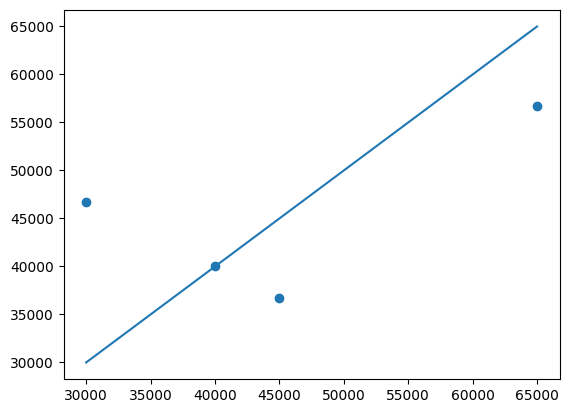

In [10]:
import matplotlib.pyplot as plt
plt.scatter(y,y_pred)
plt.plot([y.min(),y.max()],[y.min(),y.max()])
plt.show()